# Load QM9 Dataset

In [15]:
import os
from pathlib import Path
from torch_geometric.datasets import QM9

DATA_ROOT = Path.cwd().parent / "data" / "QM9"

dataset = QM9(DATA_ROOT)

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_mol_pos = real_mol.pos.flatten()

/home/doterog/repos/uva/research/drifting-experiments/.venv/lib/python3.11/site-packages/torch_geometric/data/dataset.py:115: UserWarning: The `pre_transform` argument differs from the one used in the pre-processed version of this dataset. If you want to make use of another pre-processing technique, pass `force_reload=True` explicitly to reload the dataset.
  self._process()


Number of nodes: 5


# Define MLP

In [16]:
from torch import nn

class DummyModel(nn.Module):
    def __init__(self, num_nodes: int):
        super().__init__()
        self.layer = nn.Linear(num_nodes * 3, num_nodes * 3)

    def forward(self, noise):
        return self.layer(noise)

# Aux fns

In [67]:
import matplotlib.pyplot as plt
import torch

def visualize_both_molecules(gen_mol: torch.Tensor, real_mol: torch.Tensor):
    gen_mol = gen_mol.view(-1, 3).detach().numpy()
    real_mol = real_mol.view(-1, 3).detach().numpy()
    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(gen_mol[:, 0], gen_mol[:, 1], gen_mol[:, 2], color='red', label='Generated Molecule')
    ax1.set_title('Generated Molecule')
    ax1.legend()
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(real_mol[:, 0], real_mol[:, 1], real_mol[:, 2], color='blue', label='Real Molecule')
    ax2.set_title('Real Molecule')
    ax2.legend()
    plt.show()

def plot_loss(loss_list):
    plt.plot(loss_list)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

def get_sorted_mols(gen_mols, real_mol):
    dists = torch.cdist(gen_mols, real_mol)
    closest_indices = torch.argsort(dists, dim=0)
    return gen_mols[closest_indices]

# Sample Single Noise ONCE

Iter 99: Loss = 0.4025488793849945
Iter 199: Loss = 0.26194995641708374
Iter 299: Loss = 0.17045821249485016
Iter 399: Loss = 0.11092201620340347
Iter 499: Loss = 0.07218010723590851
Iter 599: Loss = 0.04696963354945183
Iter 699: Loss = 0.03056446649134159
Iter 799: Loss = 0.019889170303940773
Iter 899: Loss = 0.012942449189722538
Iter 999: Loss = 0.008422027342021465
Iter 1099: Loss = 0.0054804603569209576
Iter 1199: Loss = 0.0035662841983139515
Iter 1299: Loss = 0.0023206814657896757
Iter 1399: Loss = 0.001510131754912436
Iter 1499: Loss = 0.0009826883906498551
Iter 1599: Loss = 0.0006394621450453997
Iter 1699: Loss = 0.0004161197866778821
Iter 1799: Loss = 0.0002707811363507062
Iter 1899: Loss = 0.0001762041065376252
Iter 1999: Loss = 0.00011466131400084123


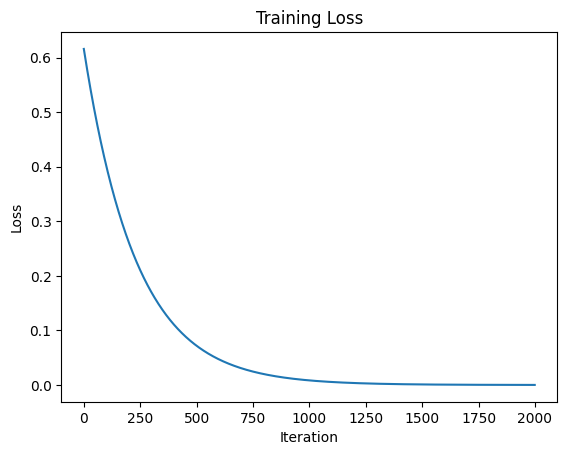

In [55]:
import torch
import torch.nn.functional as F

NUM_ITERS = 2000
LR = 0.001

# Sample noise once with the same shape
# as the real molecules
noise = torch.randn_like(real_mol.pos).flatten()

# Instantiate model and optimizer
model = DummyModel(num_nodes=real_mol.num_nodes)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    gen_mol = model(noise)
    V = real_mol_pos - gen_mol
    gen_mol_drifted = (gen_mol + V).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

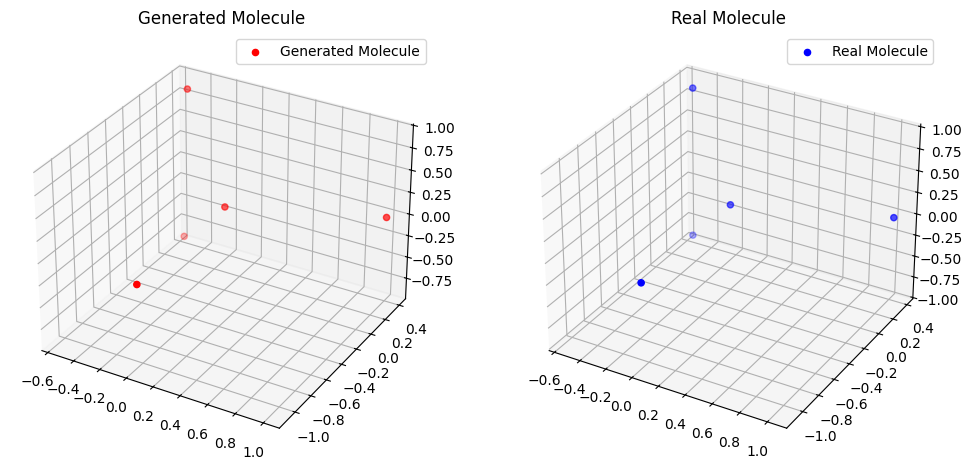

In [56]:
visualize_both_molecules(gen_mol, real_mol_pos)

# Sample Multiple Noise ONCE

Iter 499: Loss = 0.29732373356819153
Iter 999: Loss = 0.19469380378723145
Iter 1499: Loss = 0.13218849897384644
Iter 1999: Loss = 0.09244544804096222
Iter 2499: Loss = 0.06627626717090607
Iter 2999: Loss = 0.04868012294173241
Iter 3499: Loss = 0.036664169281721115
Iter 3999: Loss = 0.028327055275440216
Iter 4499: Loss = 0.02243410237133503
Iter 4999: Loss = 0.018179500475525856
Iter 5499: Loss = 0.015036609955132008
Iter 5999: Loss = 0.012660088948905468
Iter 6499: Loss = 0.010821804404258728
Iter 6999: Loss = 0.009369435720145702
Iter 7499: Loss = 0.008199806325137615
Iter 7999: Loss = 0.007241855375468731
Iter 8499: Loss = 0.0064456770196557045
Iter 8999: Loss = 0.005775563418865204
Iter 9499: Loss = 0.005205410532653332
Iter 9999: Loss = 0.004715752322226763


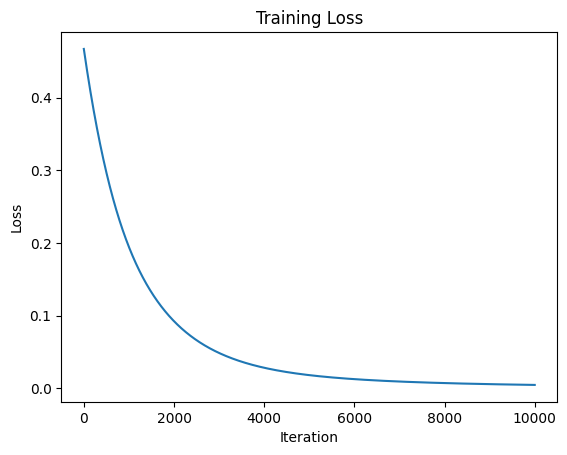

In [57]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def compute_drifting_field(gen_mol, real_mol, sigma = 1.0):
    n_gen = gen_mol.size(0)
    n_real = real_mol.size(0)

    targets = torch.cat([gen_mol, real_mol], dim=0)

    # [N_gen, N_targets, D]
    diffs = targets.unsqueeze(0) - gen_mol.unsqueeze(1)

    # [N_gen, N_targets]
    sq_dists = (diffs * diffs).sum(dim=-1)

    kernel = torch.exp(-sq_dists / (2 * sigma**2))

    kernel_neg, kernel_pos = torch.split(kernel, [n_gen, n_real], dim=1)
    diffs_neg, diffs_pos = torch.split(diffs, [n_gen, n_real], dim=1)

    weighted_neg = kernel_neg.unsqueeze(-1) * diffs_neg
    weighted_pos = kernel_pos.unsqueeze(-1) * diffs_pos

    Z_neg = kernel_neg.sum(dim=1, keepdim=True)
    Z_pos = kernel_pos.sum(dim=1, keepdim=True)

    v_neg = weighted_neg.sum(dim=1) / (Z_neg + 1e-8)
    v_pos = weighted_pos.sum(dim=1) / (Z_pos + 1e-8)
    return v_pos - v_neg

NUM_ITERS = 10000
N_GEN_MOLS = 10
LR = 0.001

# Instantiate model and optimizer
model = DummyModel(num_nodes=real_mol.num_nodes)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

# Sample noise once but for multiple molecules
# as the real molecules
noise = torch.randn((N_GEN_MOLS, real_mol_pos.size(0)))

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    gen_mol = model(noise)
    V = compute_drifting_field(gen_mol, real_mol_pos.unsqueeze(0))
    gen_mol_drifted = (gen_mol + V).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 500 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

In [69]:
sorted_mols = get_sorted_mols(gen_mol.view(-1, 3), real_mol_pos.view(-1, 3))

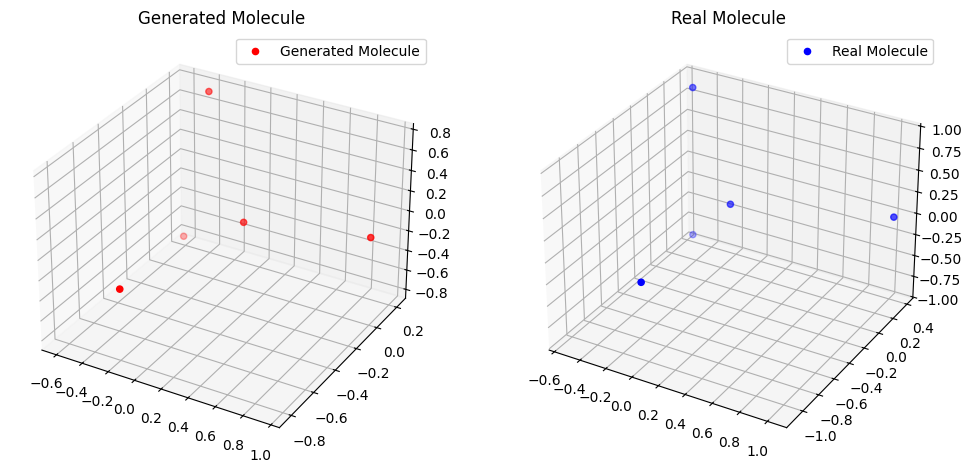

In [74]:
visualize_both_molecules(sorted_mols[1], real_mol_pos)

# Sample DIFFERENT noise every time

Iter 499: Loss = 0.3302655518054962
Iter 999: Loss = 0.3212674558162689
Iter 1499: Loss = 0.2586965262889862
Iter 1999: Loss = 0.2581215500831604
Iter 2499: Loss = 0.20071972906589508
Iter 2999: Loss = 0.16856911778450012
Iter 3499: Loss = 0.14979806542396545
Iter 3999: Loss = 0.12675227224826813
Iter 4499: Loss = 0.12414474785327911
Iter 4999: Loss = 0.1198040172457695
Iter 5499: Loss = 0.0853407084941864
Iter 5999: Loss = 0.0705001950263977
Iter 6499: Loss = 0.06585947424173355
Iter 6999: Loss = 0.05784691497683525
Iter 7499: Loss = 0.06316327303647995
Iter 7999: Loss = 0.04464403912425041
Iter 8499: Loss = 0.045093122869729996
Iter 8999: Loss = 0.036625154316425323
Iter 9499: Loss = 0.03510220721364021
Iter 9999: Loss = 0.027605270966887474


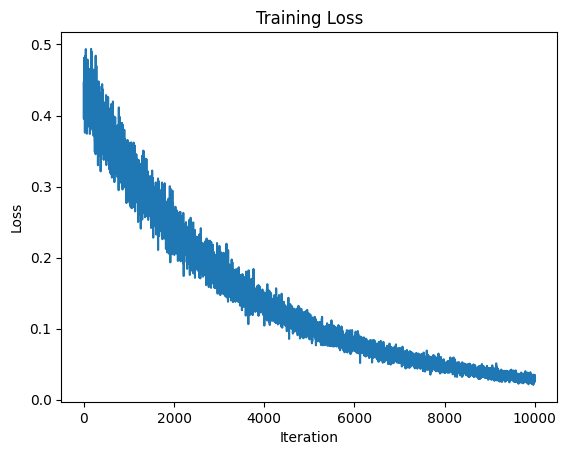

In [79]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def compute_drifting_field(gen_mol, real_mol, sigma = 1.0):
    n_gen = gen_mol.size(0)
    n_real = real_mol.size(0)

    targets = torch.cat([gen_mol, real_mol], dim=0)

    # [N_gen, N_targets, D]
    diffs = targets.unsqueeze(0) - gen_mol.unsqueeze(1)

    # [N_gen, N_targets]
    sq_dists = (diffs * diffs).sum(dim=-1)

    kernel = torch.exp(-sq_dists / (2 * sigma**2))

    kernel_neg, kernel_pos = torch.split(kernel, [n_gen, n_real], dim=1)
    diffs_neg, diffs_pos = torch.split(diffs, [n_gen, n_real], dim=1)

    weighted_neg = kernel_neg.unsqueeze(-1) * diffs_neg
    weighted_pos = kernel_pos.unsqueeze(-1) * diffs_pos

    Z_neg = kernel_neg.sum(dim=1, keepdim=True)
    Z_pos = kernel_pos.sum(dim=1, keepdim=True)

    v_neg = weighted_neg.sum(dim=1) / (Z_neg + 1e-8)
    v_pos = weighted_pos.sum(dim=1) / (Z_pos + 1e-8)
    return v_pos - v_neg

NUM_ITERS = 10000
N_GEN_MOLS = 100
LR = 0.001

# Instantiate model and optimizer
model = DummyModel(num_nodes=real_mol.num_nodes)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()

    # Sample noise once but for multiple molecules
    # as the real molecules
    noise = torch.randn((N_GEN_MOLS, real_mol_pos.size(0)))

    gen_mol = model(noise)
    V = compute_drifting_field(gen_mol, real_mol_pos.unsqueeze(0))
    gen_mol_drifted = (gen_mol + V).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 500 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

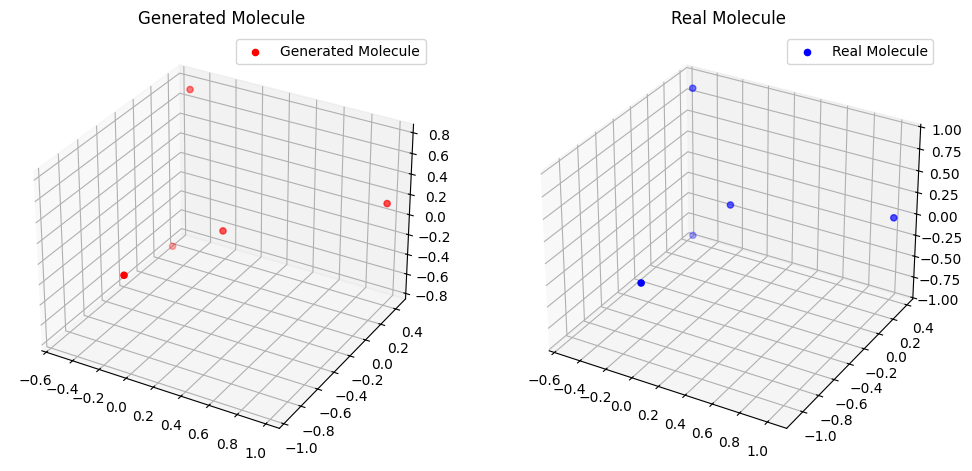

In [82]:
sorted_mols = get_sorted_mols(gen_mol.view(-1, 3), real_mol_pos.view(-1, 3))
visualize_both_molecules(sorted_mols[0], real_mol_pos)